In [63]:
import pandas as pd
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("./Social_Network_Ads.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [71]:
X_columns = ["Age", "EstimatedSalary"]

X = df.loc[:, X_columns]
y = df["Purchased"]

X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1997, test_size=0.2)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
n_neighbors = int(math.sqrt(len(X_train))) * 2
model = KNeighborsClassifier(n_neighbors=n_neighbors)
# model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [74]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Matriz de confusión: \n", confusion_matrix(y_pred, y_test))
print("Report", classification_report(y_pred, y_test))

Accuracy:  0.8375
Matriz de confusión: 
 [[46  7]
 [ 6 21]]
Report               precision    recall  f1-score   support

           0       0.88      0.87      0.88        53
           1       0.75      0.78      0.76        27

    accuracy                           0.84        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.84      0.84      0.84        80



array([0])

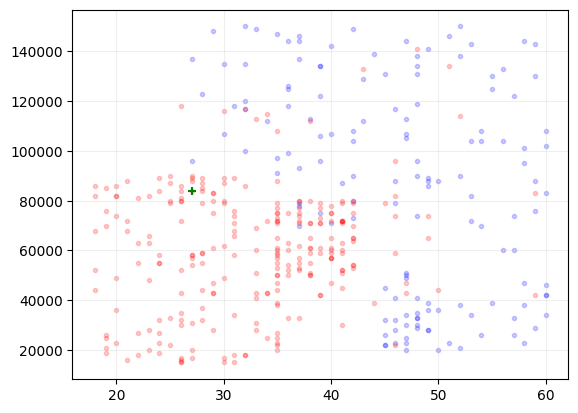

In [ ]:
new_person = pd.DataFrame([[27, 184_000]], columns=X_columns)
new_person_scaled = scaler.transform(new_person)

pred = model.predict(new_person_scaled)

yes = df[df["Purchased"] == 1]
no = df[df["Purchased"] == 0]

plt.scatter(yes["Age"], yes["EstimatedSalary"], color="blue", alpha=0.2, marker=".")
plt.scatter(no["Age"], no["EstimatedSalary"], color="red", alpha=0.2, marker=".")
plt.scatter(new_person["Age"], new_person["EstimatedSalary"], color="green", alpha=1, marker="+")
plt.grid(True, alpha=0.2)

pred